# Large Language Models (LLMs) for Text Classification Benchmark

**Author:** Alireza Mirzadeh  
**Project:** LLM Text Classification Benchmark  
**Dataset:** Rotten Tomatoes (Hugging Face Datasets)  
**Notebook:** 03 — Transformer Models 

---

## Project Overview

This project provides a comprehensive benchmark of text classification techniques, progressing from classical machine learning methods to transformer-based models and large language models (LLMs). The implementation emphasizes reproducibility, modular software design, and rigorous experimental evaluation.

### Project Links

- **GitHub Repository:** *[llm-text-classification-benchmark](https://github.com/Alireza-Mirzadeh/llm-text-classification-benchmark)*

- **LinkedIn:** *[Alireza Mirzadeh](https://www.linkedin.com/in/alireza-mirzadeh/)*

---

# Transformer-based text classification

## Objective


In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from src.data_loader import RottenTomatoesDataLoader

import pandas as pd
import matplotlib.pyplot as plt

from src.models.hf_pipeline_classifier import HuggingFacePipelineClassifier
from src.evaluation import evaluate_classifier, plot_confusion_matrix

from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

from sklearn.metrics.pairwise import cosine_similarity

import numpy as np
import torch

FIGURES_DIR = Path("../reports/figures/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# 0- Data Preparation

In [3]:
# Load the Rotten Tomatoes dataset using the data_loader from the src
loader = RottenTomatoesDataLoader()

dataset = loader.load_dataset_local()

# Create train, validation, and test splits
train_ds = dataset["train"]
validation_ds = dataset["validation"]
test_ds = dataset["test"]

# Convert to pands DataFrames
train_df = train_ds.to_pandas()
validation_df = validation_ds.to_pandas()
test_df = test_ds.to_pandas()

print(f"Train dataset shape: {train_df.shape}")
print(f"Validation dataset shape: {validation_df.shape}")
print(f"Test dataset shape: {test_df.shape}")


2026-07-13 16:49:20,699 - INFO - Loading dataset from local_path: /home/alireza/Work/llm-text-classification-benchmark/data/raw/rotten_tomatoes


Train dataset shape: (8530, 2)
Validation dataset shape: (1066, 2)
Test dataset shape: (1066, 2)


In [4]:
# Display class distribution for each split
for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    print(
        f"{split_name.capitalize()} dataset class distribution: \n\n{split_df['label'].value_counts(normalize=True)}\n"
    )


Train dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64



# 1- Task-specific Sentiment Model

Model:
cardiffnlp/twitter-roberta-base-sentiment-latest

In [5]:
# Load congifuration
config = loader.config

# Initialize the HuggingFacePipelineClassifier with the specified model name, batch size, and device from the configuration
model = HuggingFacePipelineClassifier(
    model_name=config["models"]["task_specific"]["model_name"],
    batch_size=config["models"]["task_specific"]["batch_size"],
    device=config["models"]["task_specific"]["device"],
)

# Initialize the model (this will load the pre-trained model and tokenizer)
model.fit()

2026-07-13 16:49:20,781 - INFO - Loading Hugging Face pipeline for model: cardiffnlp/twitter-roberta-base-sentiment-latest
2026-07-13 16:49:20,979 - INFO - HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 16:49:20,995 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment-latest/3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7/config.json "HTTP/1.1 200 OK"
2026-07-13 16:49:21,153 - INFO - HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-13 16:49:21,155 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-13 16:49:21,272 - INFO - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sen

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-07-13 16:49:21,404 - INFO - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest/commits/main "HTTP/1.1 200 OK"
2026-07-13 16:49:21,517 - INFO - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-13 16:49:21,535 - INFO - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest/discussions?p=0 "HTTP/1.1 200 OK"
2026-07-13 16:49:21

,model_name,'cardiffnlp/twitter-roberta-base-sentiment-latest'
,batch_size,32
,device,'auto'


In [6]:
# Predict on the test set
y_pred = model.predict(test_ds, verbose=True)


Predicting:   0%|          | 0/1066 [00:00<?, ?it/s]

Output: [{'label': 'positive', 'score': 0.9546052813529968}, {'label': 'neutral', 'score': 0.04023350402712822}, {'label': 'negative', 'score': 0.005161245819181204}]
Scores: {'positive': 0.9546052813529968, 'neutral': 0.04023350402712822, 'negative': 0.005161245819181204}
Prediction: 1 

Output: [{'label': 'positive', 'score': 0.8883834481239319}, {'label': 'neutral', 'score': 0.10391010344028473}, {'label': 'negative', 'score': 0.007706442382186651}]
Scores: {'positive': 0.8883834481239319, 'neutral': 0.10391010344028473, 'negative': 0.007706442382186651}
Prediction: 1 

Output: [{'label': 'negative', 'score': 0.7359192967414856}, {'label': 'neutral', 'score': 0.24242673814296722}, {'label': 'positive', 'score': 0.021653952077031136}]
Scores: {'negative': 0.7359192967414856, 'neutral': 0.24242673814296722, 'positive': 0.021653952077031136}
Prediction: 0 

Output: [{'label': 'positive', 'score': 0.9342907667160034}, {'label': 'neutral', 'score': 0.06267116218805313}, {'label': 'negati

In [7]:
# Inspect the predictions with a DataFrame containing the text, true labels, and predicted labels
y_pred_df = pd.DataFrame(
    {"text": test_ds["text"], "true_label": test_ds["label"], "predicted_label": y_pred}
)
y_pred_df

,text,true_label,predicted_label
0,lovingly photographed in the manner of a golde...,1,1
1,consistently clever and suspenseful .,1,1
2,"it's like a "" big chill "" reunion of the baade...",1,0
3,the story gives ample opportunity for large-sc...,1,1
4,"red dragon "" never cuts corners .",1,1
...,...,...,...
1061,a terrible movie that some people will neverth...,0,0
1062,there are many definitions of 'time waster' bu...,0,0
1063,"as it stands , crocodile hunter has the hurrie...",0,0
1064,the thing looks like a made-for-home-video qui...,0,0


In [8]:
# Evaluate the model's performance on the test set using accuracy, precision, recall, and F1-score
metrics, report = evaluate_classifier(test_ds["label"], y_pred)

print("Task-Specific Transformer Sentiment Model")

for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.2f}")

Task-Specific Transformer Sentiment Model
accuracy: 0.80
precision: 0.86
recall: 0.72
f1: 0.78


In [9]:
# Create a DataFrame from the classification report for better visualization
report_df_sentiment_model = pd.DataFrame(report).transpose()

report_df_sentiment_model

,precision,recall,f1-score,support
negative,0.758900,0.879925,0.814944,533.000000
positive,0.857143,0.720450,0.782875,533.000000
accuracy,0.800188,0.800188,0.800188,0.800188
macro avg,0.808021,0.800188,0.798909,1066.000000
weighted avg,0.808021,0.800188,0.798909,1066.000000


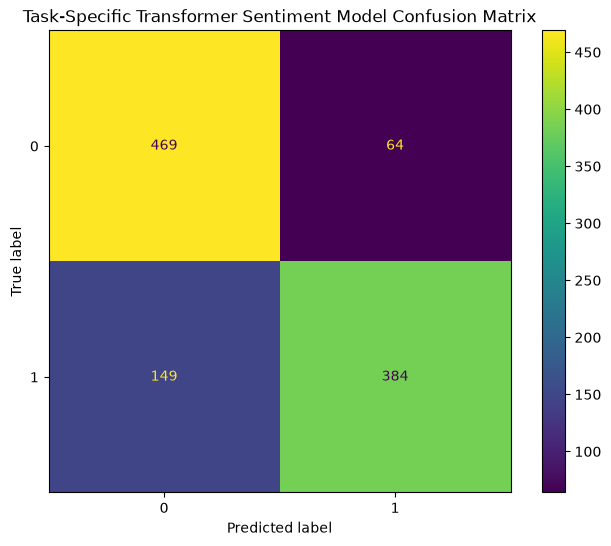

In [10]:
# Confusion matrix for the task-specific transformer sentiment model
plot_confusion_matrix(
    "Task-Specific Transformer Sentiment Model", test_ds["label"], y_pred
)

plt.show()

In [11]:
# Load benchmark results for comparison
benchmark_results_path = Path("../reports/results/benchmark_results.csv")

benchmark_df = pd.read_csv(benchmark_results_path)

results = []
results.append({"model": "Task-Specific Transformer (cardiffnlp)", **metrics})
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

# Drop the "Rank" column from the benchmark DataFrame
benchmark_df.drop(columns=["Rank"], inplace=True)

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = benchmark_df.sort_values(by="f1", ascending=False).reset_index(drop=True)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
2,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
3,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
4,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
5,Majority Class Baseline,0.500,0.000,0.000,0.000


# 2-Classification Tasks that leverages Embeddings

## 2.1- Supervised Classification with Embeddings

Embedding Model:
- sentence-transformers/all-mpnet-base-v2

Classifier:
- Logistic Regression


In [12]:
# Initialize the embedding model using the SentenceTransformer class with the specified model name from the configuration. This model will be used to generate embeddings for the text data.
embedding_model = SentenceTransformer(config["models"]["embeddings"]["model_name"])


2026-07-13 16:50:25,859 - INFO - No device provided, using cpu
2026-07-13 16:50:26,054 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 16:50:26,070 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/modules.json "HTTP/1.1 200 OK"
2026-07-13 16:50:26,177 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 16:50:26,191 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-07-13 16:50:26,194 - INFO - Loading SentenceTransformer model from sentence-transformers/all-mpnet-base-v2.
2026-07-

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-07-13 16:50:27,307 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-07-13 16:50:27,417 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-07-13 16:50:27,528 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-07-13 16:50:27,641 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-07-13 16:50:27,825 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 16:50:27,843 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/s

The `all-mpnet-base-v2` model converts text into a 768-dimensional dense vector representation.

Unlike TF-IDF, embeddings capture semantic similarity between words and sentences.

For example:

"the movie was excellent"

and

"this film was amazing"

will have similar vector representations.

In [13]:
# Generate embeddings for the training data
train_embeddings = embedding_model.encode(
    train_ds["text"],
    batch_size=config["models"]["embeddings"]["batch_size"],
    show_progress_bar=True,
)

# Generate embeddings for the test data
test_embeddings = embedding_model.encode(
    test_ds["text"],
    batch_size=config["models"]["embeddings"]["batch_size"],
    show_progress_bar=True,
)


Batches:   0%|          | 0/267 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

In [14]:
# print the shape of the generated embeddings for the training data and test data to verify the dimensions
print(f"Training embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Training embeddings shape: (8530, 768)
Test embeddings shape: (1066, 768)


In [15]:
# Train logistic regression classifier on the generated embeddings
classifier = LogisticRegression(max_iter=1000, random_state=42)

# Fit the logistic regression classifier on the training embeddings and labels
classifier.fit(train_embeddings, train_ds["label"])


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [16]:
# Make predictions on the test embeddings using the trained logistic regression classifier
y_pred_embeddings = classifier.predict(test_embeddings)

print(f"Prediction shape: {y_pred_embeddings.shape}")

Prediction shape: (1066,)


In [17]:
# Evaluate the model's performance on the test set using accuracy, precision, recall, and F1-score
metrics_embeddings, report_embeddings = evaluate_classifier(
    test_ds["label"], y_pred_embeddings
)

print("Embedding-based Logistic Regression Model")

for metric_name, metric_value in metrics_embeddings.items():
    print(f"{metric_name}: {metric_value:.2f}")


Embedding-based Logistic Regression Model
accuracy: 0.85
precision: 0.86
recall: 0.85
f1: 0.85


In [18]:
# Create a DataFrame from the classification report for better visualization
report_df_embeddings = pd.DataFrame(report_embeddings).transpose()
report_df_embeddings

,precision,recall,f1-score,support
negative,0.847866,0.857411,0.852612,533.000000
positive,0.855787,0.846154,0.850943,533.000000
accuracy,0.851782,0.851782,0.851782,0.851782
macro avg,0.851827,0.851782,0.851778,1066.000000
weighted avg,0.851827,0.851782,0.851778,1066.000000


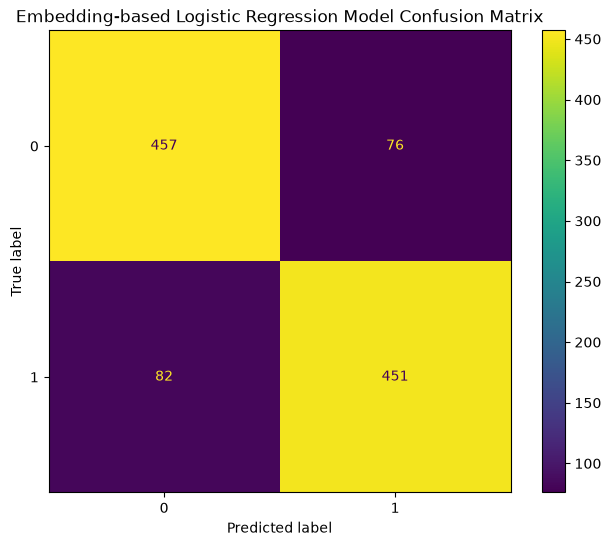

In [19]:
# Confusion matrix for the embedding-based logistic regression model
plot_confusion_matrix(
    "Embedding-based Logistic Regression Model", test_ds["label"], y_pred_embeddings
)
plt.show()


In [20]:
# Add the embedding-based logistic regression model results to the benchmark results DataFrame
results.append(
    {
        "model": "Embedding-based Logistic Regression (all-mpnet-base-v2)",
        **metrics_embeddings,
    }
)
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

benchmark_df = benchmark_df.drop_duplicates(subset=["model"], keep="last")

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = benchmark_df.sort_values(by="f1", ascending=False).reset_index(drop=True)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Embedding-based Logistic Regression (all-mpnet...,0.852,0.856,0.846,0.851
2,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
3,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
4,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
5,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
6,Majority Class Baseline,0.500,0.000,0.000,0.000


## Results Discussion

The embedding-based classification approach achieved the best performance among the evaluated models, reaching an accuracy of **85.2%** and an F1-score of **85.1%**.

Compared with traditional sparse representations such as Bag-of-Words and TF-IDF, sentence embeddings provide richer semantic representations by capturing contextual meaning beyond individual word frequencies. This allows the classifier to better distinguish sentiment patterns in movie reviews.

Interestingly, the frozen sentence embedding approach also outperformed the task-specific sentiment transformer model. One possible explanation is the domain difference between the models: the task-specific transformer was trained on Twitter sentiment data, while the Rotten Tomatoes dataset contains longer and more formal movie reviews. The general-purpose sentence embedding model may therefore provide representations that transfer better to this domain.

These results highlight the effectiveness of combining pretrained language representations with lightweight classical classifiers.

## 2.2- Zero-shot Classification with Sentence Embeddings

## Zero-Shot Classification using Semantic Similarity

Unlike the previous experiment, this approach does **not** train a classifier.

Instead, both the documents and the class descriptions are embedded into the same semantic vector space. Predictions are obtained by assigning each document to the label whose embedding has the highest cosine similarity.

Pipeline:

Review

    ↓

Sentence Transformer

    ↓

Embedding

    ↓
Cosine Similarity of Review Embedding with Class Embeddings

    ↓
Prediction

In [21]:
# Label Embeddings for Zero-shot Classification
labels_description = ["A negative movie review", "A positive movie review"]

# Generate embeddings for the class descriptions using the same embedding model
label_embeddings = embedding_model.encode(
    labels_description, show_progress_bar=True, convert_to_numpy=True
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
# Similarity scores between test embeddings and label embeddings for zero-shot classification
similarity_scores = cosine_similarity(test_embeddings, label_embeddings)

# Print the shape of the similarity scores to verify the dimensions
print(f"Similarity scores shape: {similarity_scores.shape}")

Similarity scores shape: (1066, 2)


In [23]:
# Predict the labels for the test set based on the highest cosine similarity scores
y_pred_zero_shot = similarity_scores.argmax(axis=1)


In [24]:
# Evaluate the zero-shot classification model's performance on the test set using accuracy, precision, recall, and F1-score
metrics_zero_shot, report_zero_shot = evaluate_classifier(
    test_ds["label"], y_pred_zero_shot
)

print("Zero-shot Classification with Sentence Embeddings")

for metric_name, metric_value in metrics_zero_shot.items():
    print(f"{metric_name}: {metric_value:.2f}")

Zero-shot Classification with Sentence Embeddings
accuracy: 0.80
precision: 0.78
recall: 0.85
f1: 0.81


In [25]:
# DataFrame from the classification report for better visualization
report_df_zero_shot = pd.DataFrame(report_zero_shot).transpose()
report_df_zero_shot

,precision,recall,f1-score,support
negative,0.830928,0.756098,0.791749,533.000000
positive,0.776248,0.846154,0.809695,533.000000
accuracy,0.801126,0.801126,0.801126,0.801126
macro avg,0.803588,0.801126,0.800722,1066.000000
weighted avg,0.803588,0.801126,0.800722,1066.000000


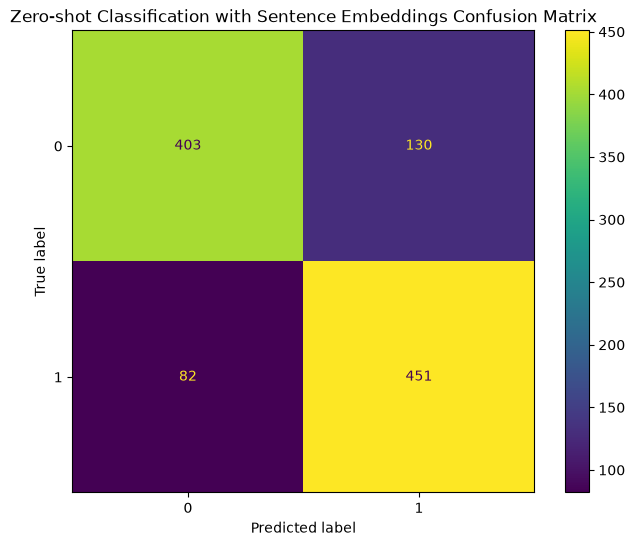

In [26]:
# Confusion matrix for the zero-shot classification model with sentence embeddings
plot_confusion_matrix(
    "Zero-shot Classification with Sentence Embeddings",
    test_ds["label"],
    y_pred_zero_shot,
)
plt.show()


In [27]:
# Add the embedding-based zero-shot model results to the benchmark results DataFrame
results.append(
    {
        "model": "Embedding Zero-Shot Classification (all-mpnet-base-v2)",
        **metrics_zero_shot,
    }
)
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

benchmark_df = benchmark_df.drop_duplicates(subset=["model"], keep="last")

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = benchmark_df.sort_values(by="f1", ascending=False).reset_index(drop=True)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Embedding-based Logistic Regression (all-mpnet...,0.852,0.856,0.846,0.851
2,Embedding Zero-Shot Classification (all-mpnet-...,0.801,0.776,0.846,0.810
3,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
4,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
5,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
6,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
7,Majority Class Baseline,0.500,0.000,0.000,0.000


# 3- Classification with Generative Language Models


## 3.1- Encoder–Decoder Models

Unlike discriminative classifiers, encoder–decoder language models generate text as output. Sentiment classification is therefore reformulated as a text generation task in which the model is prompted to produce the sentiment label.

Pipeline:

Review

   ↓

Prompt

   ↓

FLAN-T5

   ↓

Generated Text

   ↓

Sentiment Label

In [28]:
# Prompt for the generative language model to perform sentiment classification.
prompt = (
    "Is the sentiment of the following movie review "
    "positive or negative? \n\n"
    "Review: {review}"
)


In [29]:
# Prepare dataset
prompted_dataset = dataset.map(
    lambda example: {"prompt": prompt.format(review=example["text"])}
)

# Verify the prompted dataset by displaying the first few examples
prompted_dataset["test"]["prompt"][:5]

['Is the sentiment of the following movie review positive or negative? \n\nReview: lovingly photographed in the manner of a golden book sprung to life , stuart little 2 manages sweetness largely without stickiness .',
 'Is the sentiment of the following movie review positive or negative? \n\nReview: consistently clever and suspenseful .',
 'Is the sentiment of the following movie review positive or negative? \n\nReview: it\'s like a " big chill " reunion of the baader-meinhof gang , only these guys are more harmless pranksters than political activists .',
 'Is the sentiment of the following movie review positive or negative? \n\nReview: the story gives ample opportunity for large-scale action and suspense , which director shekhar kapur supplies with tremendous skill .',
 'Is the sentiment of the following movie review positive or negative? \n\nReview: red dragon " never cuts corners .']

In [30]:
# Load the Flan-T5 model and tokenizer for generative sentiment classification
model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

2026-07-13 16:56:29,266 - INFO - HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 16:56:29,284 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/config.json "HTTP/1.1 200 OK"
2026-07-13 16:56:29,396 - INFO - HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 16:56:29,410 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-13 16:56:29,528 - INFO - HTTP Request: GET https://huggingface.co/api/models/google/flan-t5-small/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-13 16:56:29,738 - INFO - HTTP Request: GET https://huggingface.co/api/models/googl

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
2026-07-13 16:56:30,805 - INFO - HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 16:56:30,818 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/generation_config.json "HTTP/1.1 200 OK"


T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

In [31]:
# Generate predictions
predictions = []

for prompt in tqdm(prompted_dataset["test"]["prompt"]):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=5,
    )

    prediction = (
        tokenizer.decode(
            outputs[0],
            skip_special_tokens=True,
        )
        .lower()
        .strip()
    )

    print(f"Generated output: {prediction}")

    if "positive" in prediction:
        predictions.append(1)

    elif "negative" in prediction:
        predictions.append(0)

    else:
        predictions.append(-1)

  0%|          | 0/1066 [00:00<?, ?it/s]

Generated output: positive
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: negative
Generated output: negative
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: positive
Generated output: negative
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: positive
Generated output: negative
G

In [32]:
# Count the number of invalid predictions (predictions with label -1) and print the result along with the total number of predictions made by the generative language model.
invalid = np.sum(np.array(predictions) == -1)

print(f"Number of invalid predictions: {invalid} out of {len(predictions)}")

Number of invalid predictions: 0 out of 1066


In [33]:
# Evaluate the generative language model's performance on the test set using accuracy, precision, recall, and F1-score
metrics_generative, report_generative = evaluate_classifier(
    test_ds["label"], predictions
)

print("Generative Language Model (Flan-T5)")

for metric_name, metric_value in metrics_generative.items():
    print(f"{metric_name}: {metric_value:.2f}")

Generative Language Model (Flan-T5)
accuracy: 0.85
precision: 0.85
recall: 0.84
f1: 0.85


In [34]:
# DataFrame from the classification report for better visualization
report_df_generative = pd.DataFrame(report_generative).transpose()
report_df_generative

,precision,recall,f1-score,support
negative,0.843866,0.851782,0.847806,533.000000
positive,0.850379,0.842402,0.846371,533.000000
accuracy,0.847092,0.847092,0.847092,0.847092
macro avg,0.847122,0.847092,0.847089,1066.000000
weighted avg,0.847122,0.847092,0.847089,1066.000000


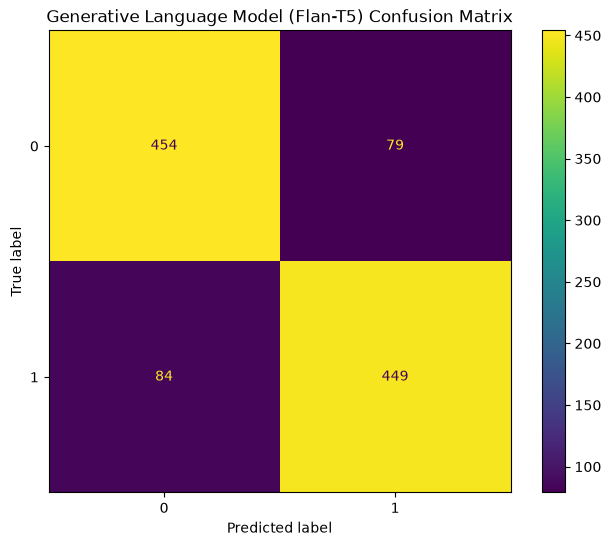

In [35]:
# Confusion matrix for the generative language model
plot_confusion_matrix(
    "Generative Language Model (Flan-T5)", test_ds["label"], predictions
)
plt.show()


In [36]:
# Add the generative encoder-decoder t5 model results to the benchmark results DataFrame
results.append(
    {
        "model": "Generative Language Model (Flan-T5 encoder-decoder)",
        **metrics_generative,
    }
)
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

benchmark_df = benchmark_df.drop_duplicates(subset=["model"], keep="last")

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = benchmark_df.sort_values(by="f1", ascending=False).reset_index(drop=True)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Embedding-based Logistic Regression (all-mpnet...,0.852,0.856,0.846,0.851
2,Generative Language Model (Flan-T5 encoder-dec...,0.847,0.850,0.842,0.846
3,Embedding Zero-Shot Classification (all-mpnet-...,0.801,0.776,0.846,0.810
4,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
5,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
6,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
7,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
8,Majority Class Baseline,0.500,0.000,0.000,0.000


# Results Summary

In [37]:
# Save the benchmark results to a CSV file
benchmark_df.to_csv("../reports/results/benchmark_results_final.csv", index=True)


In [38]:
# Display the final benchmark results in a styled table
styled_benchmark = (
    benchmark_df.style.highlight_max(
        subset=["accuracy", "precision", "recall", "f1"], color="#5EC46F3D"
    )
    .format(subset=["accuracy", "precision", "recall", "f1"], formatter="{:.3f}")
    .set_properties(**{"text-align": "center"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [("font-size", "13pt")],
            },
            {
                "selector": "caption",
                "props": [
                    ("font-size", "16pt"),
                    ("font-weight", "bold"),
                ],
            },
        ]
    )
    .set_caption("Table 2. Benchmark of All Evaluated Models for Sentiment Classification Task")
)

styled_benchmark


,model,accuracy,precision,recall,f1
Rank,,,,,
1,Embedding-based Logistic Regression (all-mpnet-base-v2),0.852,0.856,0.846,0.851
2,Generative Language Model (Flan-T5 encoder-decoder),0.847,0.850,0.842,0.846
3,Embedding Zero-Shot Classification (all-mpnet-base-v2),0.801,0.776,0.846,0.810
4,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
5,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
6,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
7,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
8,Majority Class Baseline,0.500,0.000,0.000,0.000


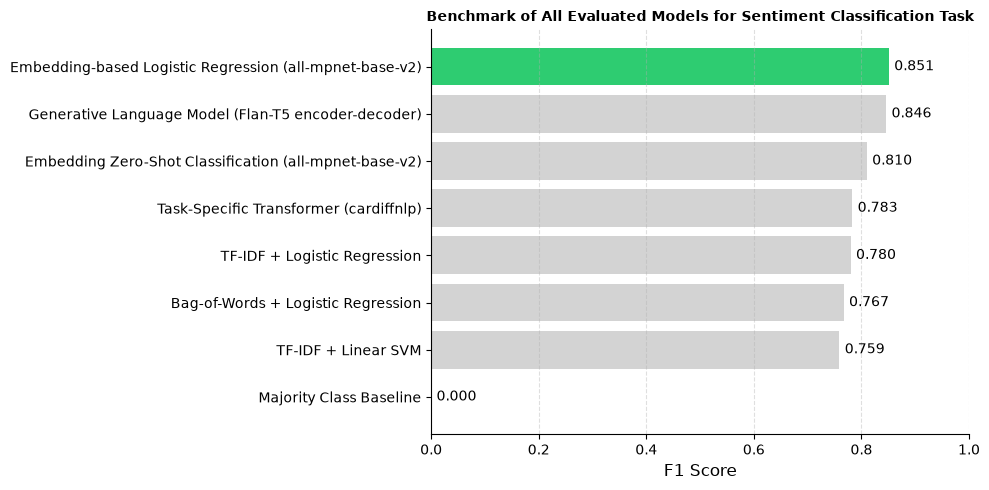

In [53]:
# Visualize the benchmark results using a horizontal bar chart

benchmark_df = benchmark_df.sort_values(by="f1", ascending=True)

# Highlight the best model
colors = [
    "#D3D3D3" if f1 != benchmark_df["f1"].max() else "#2ECC71"
    for f1 in benchmark_df["f1"]
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    benchmark_df["model"],
    benchmark_df["f1"],
    color=colors
)

# Labels on bars

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

# Formatting

ax.set_xlim(0, 1)

ax.set_xlabel("F1 Score", fontsize=12)

ax.set_ylabel("")

ax.set_title(
    "Benchmark of All Evaluated Models for Sentiment Classification Task",
    fontsize=10,
    fontweight="bold"
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

# Save figure

figure_path = FIGURES_DIR / "benchmark_results_final.png"

fig.savefig(
    figure_path
)

plt.show()


## Key Takeaways

- Transformer-based semantic embeddings significantly outperform traditional bag-of-words representations.
- Lightweight classifiers combined with strong embeddings can achieve performance comparable to larger language models.
- Generative models such as Flan-T5 provide competitive results while offering greater flexibility for instruction-based tasks.
- Model evaluation should consider multiple metrics (accuracy, precision, recall, and F1-score) rather than accuracy alone.
- The best model depends not only on performance but also on computational cost, scalability, and deployment constraints.

## Conclusion

This project benchmarked multiple approaches for sentiment classification on the Rotten Tomatoes dataset, ranging from traditional machine learning methods to modern transformer-based and generative language models.

The results demonstrate a clear progression from classical NLP techniques toward representation-based and foundation models. Traditional approaches such as Bag-of-Words and TF-IDF combined with Logistic Regression provided strong and interpretable baselines, achieving around 77–78% accuracy. However, they remain limited by their reliance on surface-level word statistics and their inability to capture deeper semantic relationships.

The best-performing model was **Embedding-based Logistic Regression using the `all-mpnet-base-v2` sentence transformer**, achieving **85.2% accuracy and an F1-score of 85.1%**. This result highlights the importance of high-quality semantic representations, as the model was able to leverage contextual embeddings while keeping the simplicity and efficiency of a lightweight classifier.

The **Flan-T5 generative language model** achieved comparable performance (**84.7% accuracy, 84.6% F1-score**), showing that instruction-tuned generative models can be effectively adapted for classification tasks. However, compared with embedding-based approaches, the generative model requires higher computational resources and more careful prompt design.

Zero-shot classification using sentence embeddings also performed well (**81.0% F1-score**), demonstrating the ability of modern language representations to generalize to classification tasks without task-specific training. Meanwhile, the fine-tuned transformer classifier (`cardiffnlp`) achieved competitive precision but lower recall, suggesting that model behavior can vary depending on the optimization objective and dataset characteristics.

Overall, the experiments show that **semantic embeddings provide an excellent balance between performance, efficiency, and scalability for sentiment classification**, while generative models offer a flexible alternative when adapting to new tasks with limited labeled data.

This benchmark highlights the importance of evaluating multiple modeling strategies rather than relying on a single architecture. Future improvements could include fine-tuning larger language models, applying parameter-efficient fine-tuning techniques such as LoRA, experimenting with larger instruction-tuned LLMs, and evaluating robustness across multiple domains and languages.